In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("Library import done.")

Library import done.


In [2]:
# ============================================================
# Part 1-2: 数据预处理 & 清洗 (与原始notebook完全一致)
# ============================================================
print("=" * 60)
print("Part 1: 数据预处理 & 清洗")
print("=" * 60)

df = pd.read_csv(r'D:\Desktop_new\机器学习与数据挖掘期末project\house_shenzhen_s.csv', encoding='gbk')
print(f"原始数据: {df.shape}")

df.drop(columns=['unitprice', 'position'], inplace=True)

rooms_split = df['rooms'].str.extract(r'(\d+)室(\d+)厅')
df['room_num'] = rooms_split[0].astype(int)
df['hall_num'] = rooms_split[1].astype(int)
df.drop(columns=['rooms'], inplace=True)

def map_height(x):
    if pd.isna(x): return np.nan
    s = str(x)
    if '高' in s: return 3
    if '中' in s: return 2
    if '低' in s: return 1
    return np.nan

df['height'] = df['height'].apply(map_height)
df['decoration'] = df['decoration'].map({'精装': 2, '简装': 1}).fillna(0).astype(int)
df['elevator'] = df['elevator'].map({'有电梯': 1, '无电梯': 0}).fillna(0).astype(int)

df['building_age'] = 2026 - df['year']
df.drop(columns=['year'], inplace=True)
valid_age = (df['building_age'] >= 0) & (df['building_age'] <= 200)
df.loc[~valid_age, 'building_age'] = df.loc[valid_age, 'building_age'].median()

df['follow'] = np.log1p(df['follow'])

for d in ['东', '南', '西', '北']:
    df[f'ori_{d}'] = df['orientation'].fillna('').apply(lambda x: 1 if d in x else 0)
df.drop(columns=['orientation'], inplace=True)

area_counts = df['area'].value_counts()
rare_areas = area_counts[area_counts < 10].index.tolist()
df['area'] = df['area'].apply(lambda x: '其他' if x in rare_areas else x)

df = pd.get_dummies(df, columns=['area'], prefix='area', dtype=int)
df = pd.get_dummies(df, columns=['buildtype'], prefix='buildtype', dtype=int)
df = pd.get_dummies(df, columns=['city'], prefix='city', dtype=int)
df.fillna(0, inplace=True)

# 清洗
n_before = len(df)
df = df[df['size'] > 0]
df = df[df['height'] > 0]
df = df[df['building_age'] <= 80]
print(f"清洗后: {df.shape} (删除 {n_before - len(df)} 行)")

# 剔除原始notebook中发现的3个低贡献特征
drop_feats = ['height', 'decoration', 'follow']
df.drop(columns=drop_feats, inplace=True)
print(f"剔除低贡献特征后: {df.shape}")

Part 1: 数据预处理 & 清洗
原始数据: (6064, 14)
清洗后: (6040, 100) (删除 24 行)
剔除低贡献特征后: (6040, 97)


In [3]:
# ============================================================
# Part 3: 准备训练/测试数据 (与原始notebook一致的划分)
# ============================================================
target_col = 'totalprice'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
y_sqrt = np.sqrt(y)  # sqrt变换，与原始一致

X_train, X_test, y_train_sqrt, y_test_sqrt = train_test_split(
    X_scaled, y_sqrt, test_size=0.2, random_state=2024
)
_, _, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, test_size=0.2, random_state=2024
)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print(f"特征数: {X_train.shape[1]}")

训练集: (4832, 96), 测试集: (1208, 96)
特征数: 96


In [4]:
# ============================================================
# Part 4: 训练 & 评估 四个模型
# ============================================================

results = {}  # 存储各模型结果

def evaluate(name, pred_sqrt):
    """将sqrt空间预测还原并计算R2和MAPE"""
    pred = pred_sqrt ** 2
    r2 = r2_score(y_test_raw, pred)
    mape = mean_absolute_percentage_error(y_test_raw, pred) * 100
    results[name] = {'R2': r2, 'MAPE': mape, 'pred': pred}
    print(f"  {name:<20}  R2={r2:.5f}  MAPE={mape:.2f}%")

print("=" * 60)
print("模型训练 & 评估")
print("=" * 60)

# --- 1. Ridge (岭回归) ---
print("\n[1] Ridge Regression (RidgeCV)")
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0], cv=5)
ridge.fit(X_train, y_train_sqrt)
print(f"    最佳alpha: {ridge.alpha_}")
evaluate("Ridge", ridge.predict(X_test))

# --- 2. Lasso (Lasso回归) ---
print("\n[2] Lasso Regression (LassoCV)")
lasso = LassoCV(alphas=[0.001, 0.01, 0.05, 0.1, 0.5, 1.0], cv=5,
                max_iter=5000, random_state=42, n_jobs=-1)
lasso.fit(X_train, y_train_sqrt)
print(f"    最佳alpha: {lasso.alpha_:.4f}")
print(f"    非零系数数: {(lasso.coef_ != 0).sum()} / {len(lasso.coef_)}")
evaluate("Lasso", lasso.predict(X_test))

# --- 3. Random Forest ---
print("\n[3] Random Forest Regressor")
rf = RandomForestRegressor(n_estimators=300, max_depth=15,
                           min_samples_leaf=5, random_state=42,
                           n_jobs=-1, verbose=0)
rf.fit(X_train, y_train_sqrt)
evaluate("Random Forest", rf.predict(X_test))

# --- 4. XGBoost (使用原始notebook最佳参数) ---
print("\n[4] XGBoost (原始notebook最佳参数)")
xgb_params = {
    'subsample': 0.8, 'reg_lambda': 0.3, 'reg_alpha': 0.3,
    'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 7,
    'learning_rate': 0.04, 'colsample_bytree': 0.8
}
xgb = XGBRegressor(**xgb_params, random_state=42, n_jobs=-1, verbosity=0,
                   objective='reg:squarederror')
xgb.fit(X_train, y_train_sqrt)
evaluate("XGBoost", xgb.predict(X_test))

模型训练 & 评估

[1] Ridge Regression (RidgeCV)


    最佳alpha: 10.0
  Ridge                 R2=0.88137  MAPE=14.44%

[2] Lasso Regression (LassoCV)


    最佳alpha: 0.0010
    非零系数数: 88 / 96
  Lasso                 R2=0.88166  MAPE=14.43%

[3] Random Forest Regressor


  Random Forest         R2=0.89820  MAPE=12.83%

[4] XGBoost (原始notebook最佳参数)


  XGBoost               R2=0.94395  MAPE=10.36%


In [5]:
# ============================================================
# Part 5: 模型性能对比汇总
# ============================================================
print("\n" + "=" * 60)
print("  模型性能对比汇总")
print("=" * 60)

summary = pd.DataFrame(results).T
summary = summary[['R2', 'MAPE']]
summary = summary.sort_values('R2', ascending=False)

print(f"\n{'模型':<20} {'R2':<12} {'MAPE':<10}")
print("-" * 42)
for model_name, row in summary.iterrows():
    print(f"{model_name:<20} {row['R2']:<12.5f} {row['MAPE']:<10.2f}%")

# 与XGBoost的差距
xgb_r2 = results['XGBoost']['R2']
xgb_mape = results['XGBoost']['MAPE']
print(f"\n--- 与XGBoost的差距 ---")
for name in ['Ridge', 'Lasso', 'Random Forest']:
    dr2 = results[name]['R2'] - xgb_r2
    dmape = results[name]['MAPE'] - xgb_mape
    print(f"  {name:<16}  ΔR2={dr2:+.5f}  ΔMAPE={dmape:+.2f}%")


  模型性能对比汇总

模型                   R2           MAPE      
------------------------------------------
XGBoost              0.94395      10.36     %
Random Forest        0.89820      12.83     %
Lasso                0.88166      14.43     %
Ridge                0.88137      14.44     %

--- 与XGBoost的差距 ---
  Ridge             ΔR2=-0.06258  ΔMAPE=+4.08%
  Lasso             ΔR2=-0.06229  ΔMAPE=+4.07%
  Random Forest     ΔR2=-0.04575  ΔMAPE=+2.47%


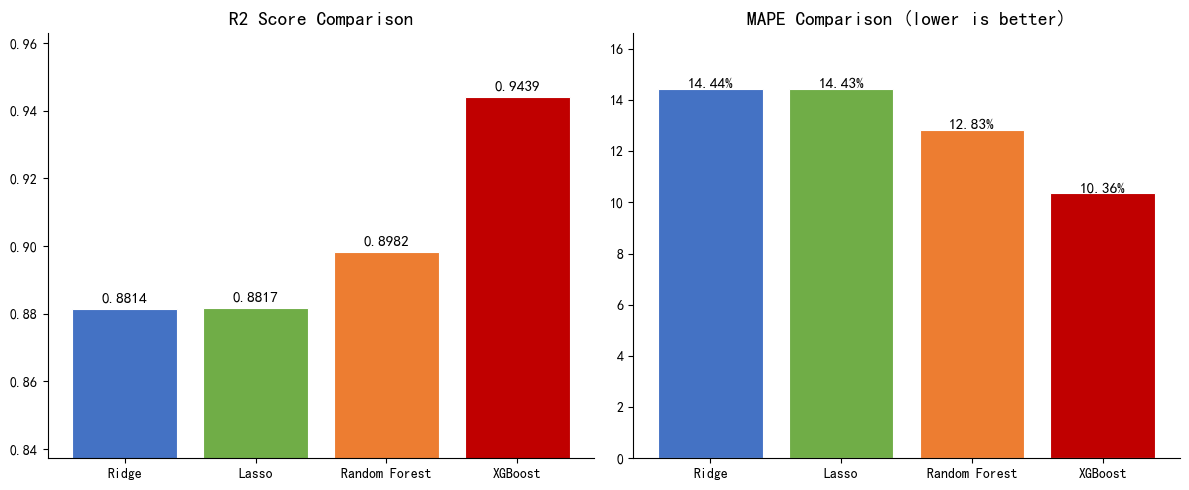


Done.


In [6]:
# ============================================================
# 补充: 简单柱状图对比
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = list(results.keys())
r2_vals = [results[m]['R2'] for m in models]
mape_vals = [results[m]['MAPE'] for m in models]
colors = ['#4472C4', '#70AD47', '#ED7D31', '#C00000']

# R2 对比
ax1 = axes[0]
bars1 = ax1.bar(models, r2_vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars1, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('R2 Score Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(min(r2_vals)*0.95, max(r2_vals)*1.02)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# MAPE 对比 (越低越好)
ax2 = axes[1]
bars2 = ax2.bar(models, mape_vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, mape_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('MAPE Comparison (lower is better)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(mape_vals)*1.15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'D:\Desktop_new\model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nDone.')